In [28]:
pip install -q emantis baccoemu

/usr/local/lib/python3.12/dist-packages/pip/_internal/metadata/importlib/_envs.py:111: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pip._vendor.pkg_resources import find_distributions


# Angular Power Spectra: Galaxy Auto & CMB Lensing Cross-Correlation

This notebook computes galaxy auto-spectra $C_\ell^{gg}$ and galaxy–CMB lensing cross-spectra $C_\ell^{\kappa g}$ using the Limber approximation and standard line-of-sight (LOS) kernels, in both GR and $f(R)$ gravity.

**References:**
- [Lin et al. (2009)](https://arxiv.org/pdf/0804.3135)
- [Karim et al. (2025)](https://arxiv.org/pdf/2408.15909)
- [Lahav et al. (2004)](https://arxiv.org/pdf/astro-ph/0310642)
- [Bianchini et al. (2015)](https://arxiv.org/pdf/1410.4502)

## Cell 1 — Imports & Logging

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d
from scipy.integrate import simpson, quad
import os
from contextlib import redirect_stdout, redirect_stderr

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

%matplotlib inline

## Cell 2 — Configuration

In [30]:
class Config:
    COSMO_PARAMS = {
        "Omega_m": 0.315,   # Total matter density parameter
        "Omega_b": 0.05,    # Baryon density parameter
        "h": 0.67,          # Reduced Hubble constant (H0 = 100h km/s/Mpc)
        "n_s": 0.96,        # Primordial scalar spectral index
        "sigma8": 0.83,     # RMS matter fluctuation amplitude at 8 Mpc/h
        "M_nu": 0.0,        # Sum of neutrino masses (eV)
        "w0": -1.0,         # Dark energy equation of state today
        "wa": 0.0,          # Time variation of dark energy equation of state
        "aexp": 1.0         # Scale factor (1.0 = present day)
    }

    TRANSFER_FUNCTION = "boltzmann_camb"  # Use Boltzmann solver (e.g., CAMB) for transfer function

    c = 299792.458        # Speed of light in km/s

# define the redshift grid for integrals

    Z_MIN = 0.01          # Minimum redshift
    Z_MAX = 3.0           # Maximum redshift
    N_Z = 500             # Number of redshift sampling points
    Z0_GALAXY = 0.3       # Characteristic galaxy redshift parameter

    ELL_MIN = 10          # Minimum multipole \u2113
    ELL_MAX = 2000        # Maximum multipole \u2113
    N_ELL = 50            # Number of \u2113 sampling points

    BIAS_B0 = 2.0         # Linear galaxy bias parameter

    alpha = 2.225         # Magnification bias parameter (Karim et al., \u03b1 \u2243 2.225)

    FR_VALUES = [4, 5, 6] # f(R) gravity parameter values (e.g., log10|fR0|)

    BACCO_K_MIN = -2      # Minimum log10(k) for power spectrum grid
    BACCO_K_MAX = None    # Maximum log10(k) (None = use default)
    BACCO_N_K = 200       # Number of k sampling points
    EMANTIS_VERBOSE = False  # Toggle emulator verbosity/logging

    FIGURE_SIZE = (14, 10)

    K_MIN_SAFETY = 1.1       # Safety factor for minimum k boundary
    K_MAX_SAFETY = 0.9       # Safety factor for maximum k boundary
    K_CLIP_THRESHOLD = 0.05  # Threshold for clipping unstable k values

---
## Core Cosmological Functions

Hubble function, comoving distance, growth factor, lensing kernels, and bias.

### Cell 3 — Hubble Function & Comoving Distance

In [31]:
# Hubble Function (Eq. 1, Lin et al., 2009)
def hubble_function(z, H0, Om_m, Om_lambda):
    return H0 * np.sqrt(
        Om_m * (1 + z)**3 +
        (1 - Om_m - Om_lambda) * (1 + z)**2 +
        Om_lambda
    )

# Comoving Distance (Eq. 146, Lahav et al., 2004)
def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    def integrand(z_prime):
        return Config.c / hubble_function(z_prime, H0, Om_m, Om_lambda)

    # Handle both scalar and array inputs
    if np.isscalar(z):
        chi, _ = quad(integrand, 0, z)
        return chi
    else:
        return np.array([quad(integrand, 0, z_val)[0] for z_val in z])

### Cell 4 — Omega(z), Lambda(z), Growth Function g(z)

In [32]:
# Omega(z) (Eq. 68, Lahav et al., 2004)
def compute_Omega_z(z, H0, Om_m, Om_lambda):
    num = Om_m * (1 + z)**3
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den


# Lambda(z) (Eq. 69, Lahav et al., 2004)
def compute_lambda_z(z, H0, Om_m, Om_lambda):
    num = Om_lambda
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den


# Growth Function g(z) (Eq. 67, Lahav et al., 2004)
def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Omega_z**(4/7) - lambda_z + (1 + Omega_z/2) * (1 + lambda_z/70)
    return (5 * Omega_z / 2) * (1 / den)

### Cell 5 — Linear Growth Factor D(z)

In [33]:
# Linear growth factor D(z) (Eq. 66, Lahav et al. (2004))
def growth_factor_D(z, H0, Om_m, Om_lambda):  #need to modify

    # Handle both scalar and array inputs
    if np.isscalar(z):
        # ---- Step 1: Compute raw (unnormalized) growth ----
        g_z = growth_function_g(z, H0, Om_m, Om_lambda)
        D_z_raw = g_z / (1.0 + z)

        # ---- Step 2: Compute today's raw value ----
        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0  # since (1+0) = 1

        # ---- Step 3: normalize so D(0) = 1 ----
        return D_z_raw / D_0_raw
    else:
        # For arrays, vectorize the computation
        g_z = np.array([growth_function_g(z_val, H0, Om_m, Om_lambda) for z_val in z])
        D_z_raw = g_z / (1.0 + z)

        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0

        return D_z_raw / D_0_raw

### Cell 6 — CMB Lensing Kernel, Galaxy Lensing Kernel, Bias Function

In [34]:
# CMB Lensing Kernel W_k(z) (Eq. 4.2, Karim et al., 2025, Eqs. (3)-(4), Bianchini et al. (2015)) (#recheck)
def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    prefactor = (3 * Om_m * H0**2) / (2 * Config.c)

    # Handle both scalar and array inputs
    if np.isscalar(z):
        chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
        return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star
    else:
        chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
        return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star


# Galaxy Lensing Kernel W_g(z) (Eq. 4.3 & 4.4, Karim et al., 2025, Eq. 6, Bianchini et al. (2015)) (#recheck)
def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    bias_term = bias_func(z) * dN_dz_func(z)
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    def integrand(z_prime):
        chi_z_prime = comoving_distance_proper(z_prime, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_z_prime) * (Config.alpha - 1) * dN_dz_func(z_prime)
    z_star = 10.0
    integral_term, _ = quad(integrand, z, z_star)
    mu_prefactor = (3 * Om_m * H0**2) / (2 * Config.c) * (1 + z) * chi_z
    mu_z = mu_prefactor * integral_term
    return bias_term + mu_z


# Bias Function (Eq. 4.7, Karim et al., 2025) #D*(z) represents the normalized growth factor
def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    D_z = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D_0 = growth_factor_D(0, H0, Omega_m, Omega_lambda)
    D_star_z = D_z / D_0
    return b0 / (D_star_z + 1e-30)

### Cell 7 — Print: "Core Cosmological Functions"

In [35]:
print("=" * 60)
print("Core Cosmological Functions")
print("=" * 60)

Core Cosmological Functions


### Cell 8 — Plot: Core Cosmological Functions

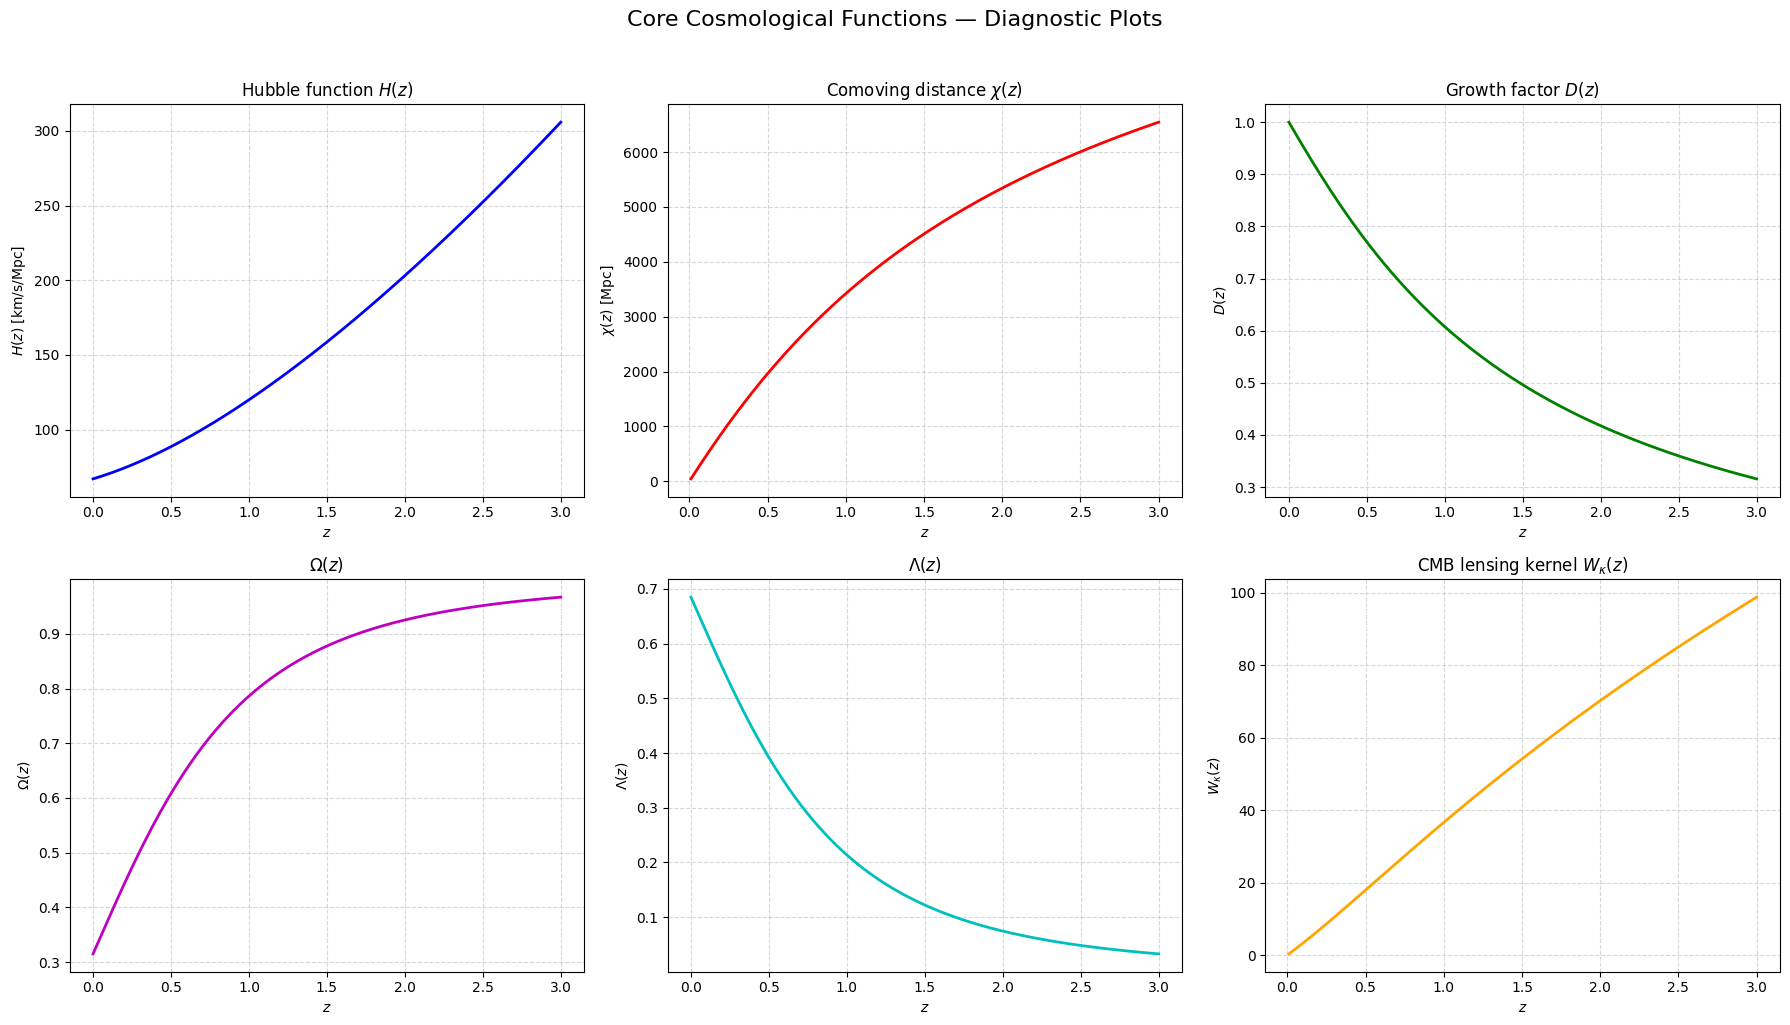

In [36]:
# Initialize cosmology
H0 = Config.COSMO_PARAMS["h"] * 100.0  # km/s/Mpc
Om_m = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m  # flat LCDM assumption for this run

z_test = np.linspace(0.0, 3.0, 300)

# 1. Hubble function H(z)
H_test = hubble_function(z_test, H0, Om_m, Om_lambda)

fig_core, axes = plt.subplots(2, 3, figsize=(18, 10))
fig_core.suptitle("Core Cosmological Functions \u2014 Diagnostic Plots", fontsize=16, y=1.02)

axes[0, 0].plot(z_test, H_test, 'b-', lw=2)
axes[0, 0].set_xlabel(r'$z$')
axes[0, 0].set_ylabel(r'$H(z)$ [km/s/Mpc]')
axes[0, 0].set_title(r'Hubble function $H(z)$')
axes[0, 0].grid(True, ls='--', alpha=0.5)

# 2. Comoving distance chi(z)
chi_test = comoving_distance_proper(z_test[1:], H0, Om_m, Om_lambda)  # skip z=0
axes[0, 1].plot(z_test[1:], chi_test, 'r-', lw=2)
axes[0, 1].set_xlabel(r'$z$')
axes[0, 1].set_ylabel(r'$\chi(z)$ [Mpc]')
axes[0, 1].set_title(r'Comoving distance $\chi(z)$')
axes[0, 1].grid(True, ls='--', alpha=0.5)

# 3. Growth factor D(z)
D_test = growth_factor_D(z_test, H0, Om_m, Om_lambda)
axes[0, 2].plot(z_test, D_test, 'g-', lw=2)
axes[0, 2].set_xlabel(r'$z$')
axes[0, 2].set_ylabel(r'$D(z)$')
axes[0, 2].set_title(r'Growth factor $D(z)$')
axes[0, 2].grid(True, ls='--', alpha=0.5)

# 4. Omega(z)
Omega_z_test = compute_Omega_z(z_test, H0, Om_m, Om_lambda)
axes[1, 0].plot(z_test, Omega_z_test, 'm-', lw=2)
axes[1, 0].set_xlabel(r'$z$')
axes[1, 0].set_ylabel(r'$\Omega(z)$')
axes[1, 0].set_title(r'$\Omega(z)$')
axes[1, 0].grid(True, ls='--', alpha=0.5)

# 5. Lambda(z)
lambda_z_test = compute_lambda_z(z_test, H0, Om_m, Om_lambda)
axes[1, 1].plot(z_test, lambda_z_test, 'c-', lw=2)
axes[1, 1].set_xlabel(r'$z$')
axes[1, 1].set_ylabel(r'$\Lambda(z)$')
axes[1, 1].set_title(r'$\Lambda(z)$')
axes[1, 1].grid(True, ls='--', alpha=0.5)

# 6. CMB lensing kernel W_kappa(z)
z_star_test = 1100.0
Wk_test = cmb_lensing_kernel(z_test[1:], z_star_test, H0, Om_m, Om_lambda)
axes[1, 2].plot(z_test[1:], Wk_test, 'orange', lw=2)
axes[1, 2].set_xlabel(r'$z$')
axes[1, 2].set_ylabel(r'$W_\kappa(z)$')
axes[1, 2].set_title(r'CMB lensing kernel $W_\kappa(z)$')
axes[1, 2].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Cell 9 — Taylor Validation: Core Cosmological Functions

In [37]:
print("--- Taylor Validation: Core Cosmological Functions ---\n")

# Taylor validation 1: H(z) at z=0 should equal H0
H_at_0 = hubble_function(0.0, H0, Om_m, Om_lambda)
print(f"  H(z=0) = {H_at_0:.4f} km/s/Mpc  (expected H0 = {H0:.4f})")
print(f"  Relative error: {abs(H_at_0 - H0)/H0:.2e}")

# Taylor validation 2: H(z) first-order Taylor expansion around z=0
# H(z) ~ H0 * sqrt(Om + OL) = H0 for flat LCDM at z=0
# dH/dz|_{z=0} ~ H0 * (3*Om/2) / sqrt(Om + OL) = H0 * 3*Om/2 for flat
dz = 1e-5
H_dz = hubble_function(dz, H0, Om_m, Om_lambda)
dHdz_numerical = (H_dz - H_at_0) / dz
dHdz_analytic = H0 * (3 * Om_m) / 2.0  # first-order coefficient for flat LCDM
print(f"\n  dH/dz|_{{z=0}} numerical  = {dHdz_numerical:.4f}")
print(f"  dH/dz|_{{z=0}} analytic   = {dHdz_analytic:.4f}")
print(f"  Relative error: {abs(dHdz_numerical - dHdz_analytic)/abs(dHdz_analytic):.2e}")

# Taylor validation 3: Comoving distance chi(z) ~ c*z/H0 for z << 1
z_small = 0.001
chi_small = comoving_distance_proper(z_small, H0, Om_m, Om_lambda)
chi_taylor = Config.c * z_small / H0
print(f"\n  chi(z={z_small}) numerical = {chi_small:.6f} Mpc")
print(f"  chi(z={z_small}) Taylor    = {chi_taylor:.6f} Mpc")
print(f"  Relative error: {abs(chi_small - chi_taylor)/chi_taylor:.2e}")

# Taylor validation 4: D(z=0) = 1 by normalization
D_at_0 = growth_factor_D(0.0, H0, Om_m, Om_lambda)
print(f"\n  D(z=0) = {D_at_0:.10f}  (expected 1.0)")
print(f"  Absolute error: {abs(D_at_0 - 1.0):.2e}")

# Taylor validation 5: Omega(z=0) should equal Om_m, Lambda(z=0) should equal Om_lambda
Omega_at_0 = compute_Omega_z(0.0, H0, Om_m, Om_lambda)
Lambda_at_0 = compute_lambda_z(0.0, H0, Om_m, Om_lambda)
print(f"\n  Omega(z=0) = {Omega_at_0:.6f}  (expected Om_m = {Om_m:.6f})")
print(f"  Lambda(z=0) = {Lambda_at_0:.6f}  (expected Om_lambda = {Om_lambda:.6f})")

# Taylor validation 6: At high z, Omega(z) -> 1 (matter domination)
z_high = 100.0
Omega_high = compute_Omega_z(z_high, H0, Om_m, Om_lambda)
print(f"\n  Omega(z={z_high}) = {Omega_high:.6f}  (expected -> 1.0 in matter domination)")

# Taylor validation 7: Bias function b(z=0) = b0 (since D*(0) = 1)
b_at_0 = bias_function(0.0, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
print(f"\n  b(z=0) = {b_at_0:.6f}  (expected b0 = {Config.BIAS_B0:.6f})")
print(f"  Relative error: {abs(b_at_0 - Config.BIAS_B0)/Config.BIAS_B0:.2e}")

--- Taylor Validation: Core Cosmological Functions ---

  H(z=0) = 67.0000 km/s/Mpc  (expected H0 = 67.0000)
  Relative error: 0.00e+00

  dH/dz|_{z=0} numerical  = 31.6577
  dH/dz|_{z=0} analytic   = 31.6575
  Relative error: 7.64e-06

  chi(z=0.001) numerical = 4.473457 Mpc
  chi(z=0.001) Taylor    = 4.474514 Mpc
  Relative error: 2.36e-04

  D(z=0) = 1.0000000000  (expected 1.0)
  Absolute error: 0.00e+00

  Omega(z=0) = 0.315000  (expected Om_m = 0.315000)
  Lambda(z=0) = 0.685000  (expected Om_lambda = 0.685000)

  Omega(z=100.0) = 0.999998  (expected -> 1.0 in matter domination)

  b(z=0) = 2.000000  (expected b0 = 2.000000)
  Relative error: 0.00e+00


---
## Power Spectrum Utilities (BACCO / EMANTIS)

### Cell 10 — Emulator Initialization Functions

In [38]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    """Initialize BACCO emulator for matter power spectrum."""
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)

            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())

            k = np.logspace(k_min, k_max, num=n_k)

            params_bacco = {
                "omega_cold": params["Omega_m"] - params["Omega_b"],
                "sigma8_cold": params["sigma8"],
                "omega_baryon": params["Omega_b"],
                "ns": params["n_s"],
                "hubble": params["h"],
                "neutrino_mass": params.get("M_nu", 0.0),
                "w0": params.get("w0", -1.0),
                "wa": params.get("wa", 0.0),
                "expfactor": params.get("aexp", 1.0)
            }

            k, Q_boost = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
            k, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)

    return k, pk_nl, Q_boost


def initialize_emantis_emulator(verbose=False):
    """Initialize EMANTIS emulator for f(R) gravity boost."""
    return NonLinearMGBoostEmulator(verbose=verbose)


def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    """Compute f(R) gravity boost."""
    params_emantis = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0
    }
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)

### Cell 11 — Power Spectrum Interpolator & k-bounds Helper

In [39]:
# Build log-log cubic interpolator for P(k) to evaluate at arbitrary k = l/chi(z)
# Convert discrete emulator P(k) into a smooth function (log-log interpolation)
# Use log-log space so P(k) interpolation is stable, smooth, and preserves power-law behavior

def create_power_spectrum_interpolator(k, pk):
    """Create log-log interpolator for P(k)."""
    return interp1d(
        np.log(k),
        np.log(pk + 1e-50),
        kind='cubic',
        bounds_error=False,
        fill_value='extrapolate'
    )


def check_k_bounds(k_vals, k_min, k_max, ell, spectrum_name, threshold=0.05):
    """Clip k values to safe bounds (simple version)."""
    return np.clip(k_vals, k_min, k_max)

---
## Angular Power Spectra (Limber approximation)

Galaxy auto spectrum $C_\ell^{gg}$ (Eq. 8, Bianchini et al. 2015) and galaxy–CMB lensing cross spectrum $C_\ell^{\kappa g}$ (Eq. 7, Bianchini et al. 2015).

### Cell 12 — C_ℓ^{gg} (Galaxy Auto Spectrum)

In [40]:
# Eq. (8), Bianchini et al. (2015)

def compute_Cl_galaxy_auto(
    ell_array, pk_interp_log, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy auto spectrum C_l^{gg}."""
    b_vals = bias_function(z_grid, H0, Om_m, Om_lambda, b0=b0)
    Wg = b_vals * dNdz

    Cl = np.zeros_like(ell_array, dtype=float)

    for i, ell in enumerate(ell_array):
        k_vals = ell / chi_vals # Limber: k = ell / chi (using standard l instead of l+1/2; see LoVerde & Afshordi 2008)

        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_l^gg")
        else:
            k_safe = k_vals

        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10

        P_kz = P0 * (D_vals / D0) ** 2

        integrand = (H_vals / c_light) * (Wg ** 2) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)

    return Cl

### Cell 13 — C_ℓ^{κg} (Galaxy–CMB Lensing Cross Spectrum)

In [41]:
# Eq. (7), Bianchini et al. (2015)

def compute_Cl_galaxy_cmb_cross(
    ell_array, pk_interp_log, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy-CMB lensing cross spectrum C_l^{kappa g}."""
    b_vals = bias_function(z_grid, H0, Om_m, Om_lambda, b0=b0)
    Wg = b_vals * dNdz

    Cl = np.zeros_like(ell_array, dtype=float)

    for i, ell in enumerate(ell_array):
        k_vals = ell / chi_vals # Limber: k = ell / chi (using standard l instead of l+1/2; see LoVerde & Afshordi 2008)

        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_l^kg")
        else:
            k_safe = k_vals

        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10

        P_kz = P0 * (D_vals / D0) ** 2

        integrand = (H_vals / c_light) * (Wkappa_vals * Wg) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)

    return Cl

### Cell 14 — Print: "Angular Power Spectra (Limber approximation)"

In [42]:
print("=" * 60)
print("Angular Power Spectra (Limber approximation)")
print("=" * 60)

Angular Power Spectra (Limber approximation)


---
## Plotting Utility

### Cell 15 — plot_power_spectra()

In [43]:
def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None,
                        fR_values=None, figsize=(14, 10)):
    """Plot C_l^gg, C_l^{kappa g} and f(R)/GR ratios."""
    fig = plt.figure(figsize=figsize)

    # C_l^{gg}
    plt.subplot(2, 2, 1)
    plt.loglog(ell, Cl_gg_gr, 'b-', linewidth=2.5,
                label=r'$C_\ell^{gg}\;[\mathrm{GR}]$')

    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["gg"]:
                plt.loglog(
                    ell, fr_results["gg"][logfR0_val], '--', linewidth=2,
                    label=rf'$C_\ell^{{gg}}[f(R):\,\log_{{10}}|f_{{R0}}|=-{logfR0_val}]$'
                )

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}$', fontsize=12)
    plt.title(r'Galaxy Auto Spectrum $C_\ell^{gg}$', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)

    # C_l^{kappa g}
    plt.subplot(2, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), 'b-', linewidth=2.5,
                label=r'$C_\ell^{\kappa g}\;[\mathrm{GR}]$')

    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["kg"]:
                plt.loglog(
                    ell, np.abs(fr_results["kg"][logfR0_val]), '--', linewidth=2,
                    label=rf'$C_\ell^{{\kappa g}}[f(R):\,\log_{{10}}|f_{{R0}}|=-{logfR0_val}]$'
                )

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
    plt.title(r'CMB Lensing $\times$ Galaxy $C_\ell^{\kappa g}$', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)

    # Ratio C_l^{gg}(fR)/C_l^{gg}(GR)
    plt.subplot(2, 2, 3)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["gg"]:
                ratio = fr_results["gg"][logfR0_val] / Cl_gg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                                label=rf'$\log_{{10}}|f_{{R0}}|=-{logfR0_val}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}(f(R))/C_\ell^{gg}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy Auto Ratio', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])

    # Ratio C_l^{kappa g}(fR)/C_l^{kappa g}(GR)
    plt.subplot(2, 2, 4)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["kg"]:
                ratio = fr_results["kg"][logfR0_val] / Cl_kg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                                label=rf'$\log_{{10}}|f_{{R0}}|=-{logfR0_val}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{\kappa g}(f(R))/C_\ell^{\kappa g}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy-CMB Cross Ratio', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])

    plt.tight_layout()
    return fig

---
## Compute Matter Power Spectra (BACCO + EMANTIS)

### Cell 16 — Initialize Emulators & GR Power Spectrum

In [44]:
k, pk_nl_gr, Q_boost = initialize_bacco_emulator(
    Config.COSMO_PARAMS,
    k_min=Config.BACCO_K_MIN,
    k_max=Config.BACCO_K_MAX,
    n_k=Config.BACCO_N_K,
    verbose=Config.EMANTIS_VERBOSE
)
pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)

emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)

### Cell 17 — Print: Interpolator Summary

In [45]:
print("=" * 60)
print("Power Spectrum Interpolator")
print("=" * 60)
print(f"  k range: [{k.min():.4e}, {k.max():.4e}] h/Mpc")
print(f"  Number of k points: {len(k)}")
print(f"  P(k) range: [{pk_nl_gr.min():.4e}, {pk_nl_gr.max():.4e}] (Mpc/h)^3")

Power Spectrum Interpolator
  k range: [1.0000e-02, 4.9032e+00] h/Mpc
  Number of k points: 200
  P(k) range: [4.1270e+01, 3.7475e+04] (Mpc/h)^3


### Cell 18 — Plot: Interpolator Diagnostic

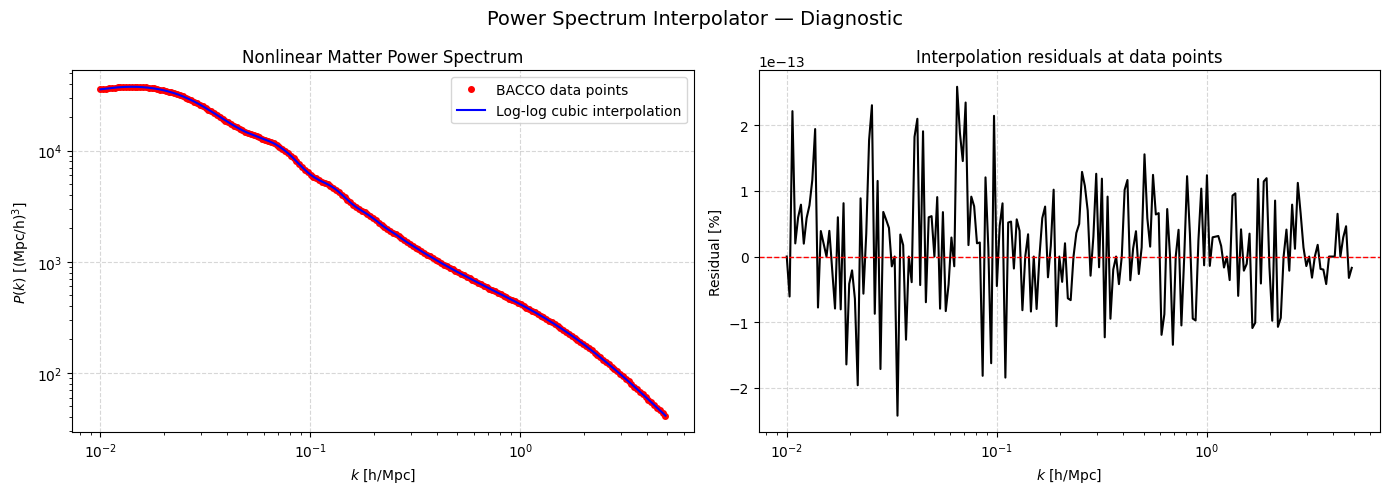

In [46]:
fig_interp, axes_interp = plt.subplots(1, 2, figsize=(14, 5))
fig_interp.suptitle("Power Spectrum Interpolator \u2014 Diagnostic", fontsize=14)

# Panel 1: P(k) raw data + interpolation
k_fine = np.logspace(np.log10(k.min()), np.log10(k.max()), 1000)
pk_interp_vals = np.exp(pk_interp_gr(np.log(k_fine)))

axes_interp[0].loglog(k, pk_nl_gr, 'ro', ms=4, label='BACCO data points')
axes_interp[0].loglog(k_fine, pk_interp_vals, 'b-', lw=1.5, label='Log-log cubic interpolation')
axes_interp[0].set_xlabel(r'$k$ [h/Mpc]')
axes_interp[0].set_ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
axes_interp[0].set_title('Nonlinear Matter Power Spectrum')
axes_interp[0].legend()
axes_interp[0].grid(True, ls='--', alpha=0.5)

# Panel 2: Residuals (interpolated at data points vs data)
pk_at_data = np.exp(pk_interp_gr(np.log(k)))
residuals = (pk_at_data - pk_nl_gr) / pk_nl_gr
axes_interp[1].semilogx(k, residuals * 100, 'k-', lw=1.5)
axes_interp[1].axhline(0, color='r', ls='--', lw=1)
axes_interp[1].set_xlabel(r'$k$ [h/Mpc]')
axes_interp[1].set_ylabel('Residual [%]')
axes_interp[1].set_title('Interpolation residuals at data points')
axes_interp[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Cell 19 — Taylor Validation: Interpolator

In [47]:
print("--- Taylor Validation: Power Spectrum Interpolator ---\n")

# Check that interpolator reproduces data points exactly
max_resid = np.max(np.abs(residuals))
mean_resid = np.mean(np.abs(residuals))
print(f"  Max |residual| at data points: {max_resid:.2e}")
print(f"  Mean |residual| at data points: {mean_resid:.2e}")
print(f"  Interpolator faithfully reproduces data: {'PASS' if max_resid < 1e-10 else 'WARN'}")

# Check monotonicity in log-log space at small k (should be ~ k^{n_s} power law)
k_small_idx = k < 0.05
if np.sum(k_small_idx) > 2:
    log_slope = np.diff(np.log(pk_nl_gr[k_small_idx])) / np.diff(np.log(k[k_small_idx]))
    print(f"\n  Effective spectral index at small k (n_eff ~ n_s): {np.mean(log_slope):.3f}")
    print(f"  (Expected near n_s = {Config.COSMO_PARAMS['n_s']})")

# Check P(k) is positive everywhere
print(f"\n  P(k) > 0 everywhere: {'PASS' if np.all(pk_nl_gr > 0) else 'FAIL'}")

--- Taylor Validation: Power Spectrum Interpolator ---

  Max |residual| at data points: 2.59e-15
  Mean |residual| at data points: 6.60e-16
  Interpolator faithfully reproduces data: PASS

  Effective spectral index at small k (n_eff ~ n_s): -0.553
  (Expected near n_s = 0.96)

  P(k) > 0 everywhere: PASS


---
## Pre-compute Redshift-Dependent Quantities

### Cell 20 — Redshift Grid, dN/dz, chi, H, D, W_kappa

In [48]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

# --- Normalized galaxy redshift distribution dN/dz ---
# Replacement for removed functions: Raw n(z) ~ exp(-z / z0)
_raw_nz = np.exp(-z_grid / Config.Z0_GALAXY)
_norm_constant = simpson(_raw_nz, z_grid)
dNdz = _raw_nz / _norm_constant

chi_vals = comoving_distance_proper(z_grid, H0, Om_m, Om_lambda)
H_vals = hubble_function(z_grid, H0, Om_m, Om_lambda)

D_vals = growth_factor_D(z_grid, H0, Om_m, Om_lambda)
D0 = growth_factor_D(0.0, H0, Om_m, Om_lambda)

# CMB lensing kernel at each z
z_star = 1100.0
Wkappa_vals = cmb_lensing_kernel(z_grid, z_star, H0, Om_m, Om_lambda)

print(f"Redshift grid: {Config.N_Z} points in [{Config.Z_MIN}, {Config.Z_MAX}]")
print(f"chi range: [{chi_vals.min():.1f}, {chi_vals.max():.1f}] Mpc")

Redshift grid: 500 points in [0.01, 3.0]
chi range: [44.6, 6544.9] Mpc


---
## Compute Angular Power Spectra for GR

### Cell 21 — C_ℓ^{gg}(GR) and C_ℓ^{κg}(GR)

In [49]:
ell = np.logspace(np.log10(Config.ELL_MIN),
                  np.log10(Config.ELL_MAX),
                  Config.N_ELL)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

Cl_gg_gr = compute_Cl_galaxy_auto(
    ell, pk_interp_gr, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)

Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
    ell, pk_interp_gr, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)

print(f"GR C_l^gg range: [{Cl_gg_gr.min():.4e}, {Cl_gg_gr.max():.4e}]")
print(f"GR C_l^kg range: [{Cl_kg_gr.min():.4e}, {Cl_kg_gr.max():.4e}]")

GR C_l^gg range: [2.2614e-06, 3.4507e-04]
GR C_l^kg range: [7.9558e-07, 1.5239e-04]


---
## Compute Angular Power Spectra for f(R) Gravity

### Cell 22 — f(R) Boost Loop

In [50]:
fr_results = {"gg": {}, "kg": {}}

for logfR0_val in Config.FR_VALUES:
    pk_boost = compute_fR_boost(
        emantis_emu, Config.COSMO_PARAMS,
        logfR0_val, k,
        aexp=Config.COSMO_PARAMS["aexp"]
    )
    pk_fR = pk_nl_gr * pk_boost
    pk_interp_fr = create_power_spectrum_interpolator(k, pk_fR)

    Cl_gg_fr = compute_Cl_galaxy_auto(
        ell, pk_interp_fr, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )

    Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
        ell, pk_interp_fr, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )

    fr_results["gg"][logfR0_val] = Cl_gg_fr
    fr_results["kg"][logfR0_val] = Cl_kg_fr

    print(f"  log10|fR0| = -{logfR0_val}: done")

print("All f(R) spectra computed.")

  log10|fR0| = -4: done
  log10|fR0| = -5: done
  log10|fR0| = -6: done
All f(R) spectra computed.


---
## Plot Results

### Cell 23 — Plot: Angular Power Spectra (GR + f(R))

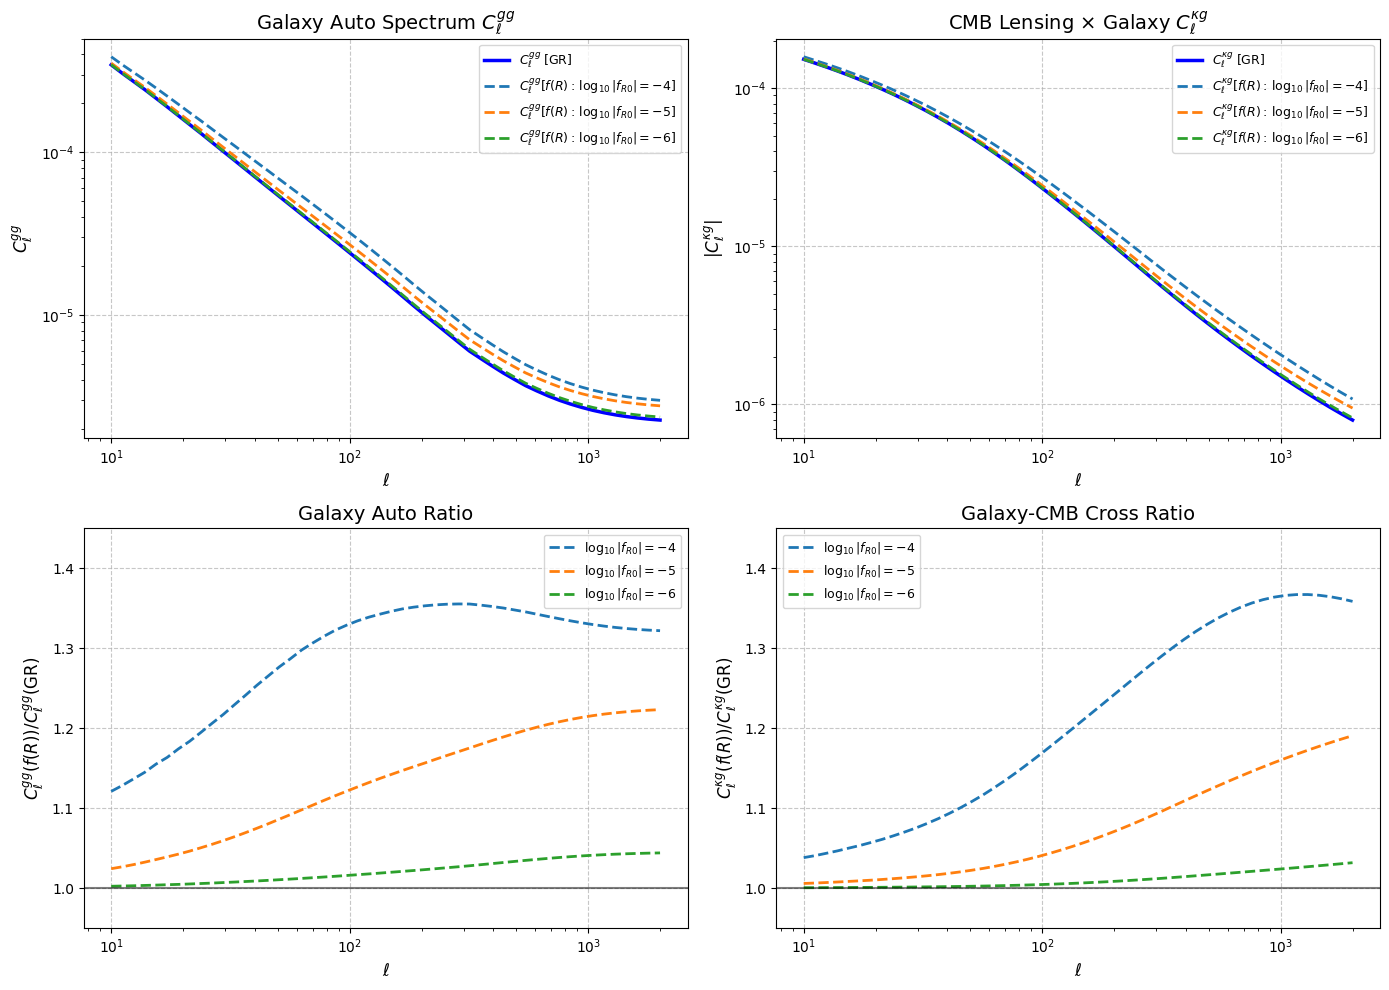

In [51]:
fig = plot_power_spectra(
    ell, Cl_gg_gr, Cl_kg_gr,
    fr_results=fr_results,
    fR_values=Config.FR_VALUES,
    figsize=Config.FIGURE_SIZE
)
plt.show()

---
## Taylor Validation: Angular Power Spectra (Limber)

### Cell 24 — Validation Checks

In [52]:
print("--- Taylor Validation: Angular Power Spectra (Limber approximation) ---\n")

# Validation 1: C_l^{gg} > 0 (auto-spectrum must be non-negative)
print(f"  C_l^{{gg}}(GR) > 0 everywhere: {'PASS' if np.all(Cl_gg_gr > 0) else 'FAIL'}")

# Validation 2: C_l^{kg} positivity (expected positive for standard kernels)
print(f"  C_l^{{kg}}(GR) > 0 everywhere: {'PASS' if np.all(Cl_kg_gr > 0) else 'WARN (may have sign changes)'}")

# Validation 3: C_l should decrease at high l (damping from P(k) turnover)
gg_slope_high = (np.log(Cl_gg_gr[-1]) - np.log(Cl_gg_gr[-5])) / (np.log(ell[-1]) - np.log(ell[-5]))
kg_slope_high = (np.log(np.abs(Cl_kg_gr[-1])) - np.log(np.abs(Cl_kg_gr[-5]))) / (np.log(ell[-1]) - np.log(ell[-5]))
print(f"\n  C_l^{{gg}} slope at high l: {gg_slope_high:.3f}  (expected < 0, i.e., decreasing)")
print(f"  C_l^{{kg}} slope at high l: {kg_slope_high:.3f}  (expected < 0, i.e., decreasing)")

# Validation 4: f(R) boost should be >= 1 (enhanced gravity -> more power)
print("\n  f(R)/GR ratios (should be >= 1.0 for stronger gravity):")
for logfR0_val in Config.FR_VALUES:
    ratio_gg = fr_results["gg"][logfR0_val] / Cl_gg_gr
    ratio_kg = fr_results["kg"][logfR0_val] / Cl_kg_gr
    print(f"    log10|fR0|=-{logfR0_val}:  C_l^{{gg}} ratio range = [{ratio_gg.min():.4f}, {ratio_gg.max():.4f}]"
          f"  C_l^{{kg}} ratio range = [{ratio_kg.min():.4f}, {ratio_kg.max():.4f}]")

# Validation 5: Ordering - stronger f(R) (smaller |logfR0|) gives larger boost
if len(Config.FR_VALUES) >= 2:
    sorted_fR = sorted(Config.FR_VALUES)
    ordering_ok_gg = True
    ordering_ok_kg = True
    for i in range(len(sorted_fR) - 1):
        r1 = np.mean(fr_results["gg"][sorted_fR[i]] / Cl_gg_gr)
        r2 = np.mean(fr_results["gg"][sorted_fR[i + 1]] / Cl_gg_gr)
        if r1 < r2:
            ordering_ok_gg = False
        r1_kg = np.mean(fr_results["kg"][sorted_fR[i]] / Cl_kg_gr)
        r2_kg = np.mean(fr_results["kg"][sorted_fR[i + 1]] / Cl_kg_gr)
        if r1_kg < r2_kg:
            ordering_ok_kg = False
    print(f"\n  f(R) ordering (stronger -> bigger boost):")
    print(f"    C_l^{{gg}}: {'PASS' if ordering_ok_gg else 'FAIL'}")
    print(f"    C_l^{{kg}}: {'PASS' if ordering_ok_kg else 'FAIL'}")

# Validation 6: Schwarz inequality |C_l^{kg}|^2 <= C_l^{kk} x C_l^{gg}
# We don't have C_l^{kk} separately, but we can check |C_l^{kg}| < C_l^{gg} as a basic sanity check
cross_less_auto = np.all(np.abs(Cl_kg_gr) <= Cl_gg_gr * 10)  # generous bound
print(f"\n  |C_l^{{kg}}| reasonably bounded by C_l^{{gg}}: {'PASS' if cross_less_auto else 'WARN'}")

# Validation 7: dN/dz normalization
dNdz_integral = simpson(dNdz, z_grid)
print(f"\n  Integral dN/dz dz = {dNdz_integral:.10f}  (expected 1.0)")
print(f"  Normalization error: {abs(dNdz_integral - 1.0):.2e}")

--- Taylor Validation: Angular Power Spectra (Limber approximation) ---

  C_l^{gg}(GR) > 0 everywhere: PASS
  C_l^{kg}(GR) > 0 everywhere: PASS

  C_l^{gg} slope at high l: -0.172  (expected < 0, i.e., decreasing)
  C_l^{kg} slope at high l: -0.889  (expected < 0, i.e., decreasing)

  f(R)/GR ratios (should be >= 1.0 for stronger gravity):
    log10|fR0|=-4:  C_l^{gg} ratio range = [1.1211, 1.3555]  C_l^{kg} ratio range = [1.0382, 1.3673]
    log10|fR0|=-5:  C_l^{gg} ratio range = [1.0243, 1.2233]  C_l^{kg} ratio range = [1.0059, 1.1907]
    log10|fR0|=-6:  C_l^{gg} ratio range = [1.0024, 1.0441]  C_l^{kg} ratio range = [1.0005, 1.0318]

  f(R) ordering (stronger -> bigger boost):
    C_l^{gg}: PASS
    C_l^{kg}: PASS

  |C_l^{kg}| reasonably bounded by C_l^{gg}: PASS

  Integral dN/dz dz = 1.0000000000  (expected 1.0)
  Normalization error: 2.22e-16
